# Problem 3: Face Detection and Recognition Pipeline

It covers:
- Detector comparison (Haar, MTCNN, optional RetinaFace)
- Alignment + augmentation visualization
- ArcFace vs Softmax training/evaluation
- Task 4A/4B/4C/4D deliverables
- Export of figures and metrics to `outputs/`

In [1]:
# # Section 1: Project setup
# %load_ext autoreload
# %autoreload 2

import json
import random
from pathlib import Path

import numpy as np
import torch

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
OUT_DIR = Path("outputs")
OUT_DIR.mkdir(exist_ok=True)

print(f"Device: {DEVICE}")
print(f"Output dir: {OUT_DIR.resolve()}")

Device: cuda
Output dir: /data/user13/dlcv_assignment/outputs


In [2]:
# Imports from modular files
import cv2
import matplotlib.pyplot as plt

from data_loader import (
    FaceDataset,
    filter_identities,
    load_lfw_arrays,
    set_seed,
    stratified_split,
)
from detectors import (
    HaarDetector,
    MTCNNDetector,
    RetinaFaceDetector,
    build_pseudo_gt,
    evaluate_detector,
)
from alignment import LandmarkAligner, build_aligned_dataset, build_transforms
from losses import ArcFaceLoss, SoftmaxHead
from models import EmbeddingNet
from train import extract_embeddings, train_model
from evaluation import (
    build_identification_protocol,
    evaluate_challenge_drop,
    evaluate_identification,
    evaluate_verification,
    classify_challenge_conditions,
    topk_gallery_matches,
)
from visualization import (
    plot_alignment_examples,
    plot_augmentations,
    plot_challenge_drop,
    plot_cmc_curves,
    plot_detector_comparison,
    plot_roc_curves,
    plot_top5_matches,
    plot_tsne_embeddings,
)

set_seed(SEED)

/data/user13/miniconda3/envs/dlcv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Dataset Loading and Preprocessing

We load the LFW dataset, filter identities, and create train/validation/test splits.

**File used:** data_loader.py

In [3]:
# Load and preprocess
all_images, all_labels, ds = load_lfw_arrays()
print(f"Loaded {len(all_images)} images")

# Keep identities with enough samples for train/val/test + gallery/probe usage
f_images, f_labels = filter_identities(all_images, all_labels, min_images_per_id=7)
splits = stratified_split(f_images, f_labels, seed=SEED)

aligner = LandmarkAligner(device=DEVICE)
aligned_imgs, unaligned_imgs, aligned_labels, failed = build_aligned_dataset(
    splits.train_images + splits.val_images + splits.test_images,
    [str(x) for x in splits.label_encoder.inverse_transform(np.concatenate([splits.train_labels, splits.val_labels, splits.test_labels]))],
    aligner,
)
print(f"Aligned samples: {len(aligned_imgs)} | failed: {failed}")

train_tf, eval_tf = build_transforms()

# Re-encode aligned labels with a shared encoder
from sklearn.preprocessing import LabelEncoder
le2 = LabelEncoder().fit(aligned_labels)
encoded = le2.transform(aligned_labels)

from sklearn.model_selection import train_test_split
idx = np.arange(len(aligned_imgs))
tr_idx, temp_idx = train_test_split(idx, test_size=0.2, stratify=encoded, random_state=SEED)

# Check if we can stratify the val/test split
temp_encoded = encoded[temp_idx]
unique, counts = np.unique(temp_encoded, return_counts=True)
can_stratify = np.all(counts >= 2)

if can_stratify:
    va_idx, te_idx = train_test_split(temp_idx, test_size=0.5, stratify=temp_encoded, random_state=SEED)
else:
    # Fall back to non-stratified split if some classes have < 2 samples
    va_idx, te_idx = train_test_split(temp_idx, test_size=0.5, random_state=SEED)

aligned_train_ds = FaceDataset([aligned_imgs[i] for i in tr_idx], encoded[tr_idx], transform=train_tf)
aligned_val_ds = FaceDataset([aligned_imgs[i] for i in va_idx], encoded[va_idx], transform=eval_tf)
aligned_test_ds = FaceDataset([aligned_imgs[i] for i in te_idx], encoded[te_idx], transform=eval_tf)

unaligned_train_ds = FaceDataset([unaligned_imgs[i] for i in tr_idx], encoded[tr_idx], transform=train_tf)

n_classes = len(le2.classes_)
print(f"Classes: {n_classes} | train={len(aligned_train_ds)} val={len(aligned_val_ds)} test={len(aligned_test_ds)}")

Loaded 13233 images
Aligned samples: 5095 | failed: 0
Classes: 256 | train=4076 val=509 test=510


### Task 1: Face Detection Pipeline

We compare classical and deep learning-based face detectors:
- Haar Cascade
- MTCNN / RetinaFace

Metrics evaluated:
- Precision, Recall, F1-score
- IoU
- Inference time

**File used:** detectors.py

RetinaFace unavailable: Install retina-face package to use RetinaFaceDetector.


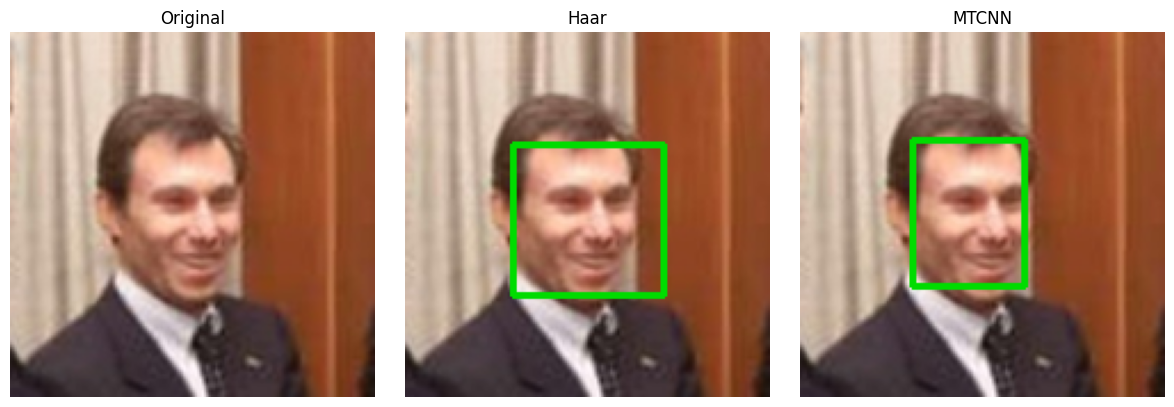

{'label': 'Haar', 'precision': 0.9669902912602583, 'recall': 0.9154411764689054, 'f1': 0.940509914512763, 'mean_iou': 0.7109173613340865, 'mean_time_ms': 12.314234285149723, 'scores': array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,

In [4]:
# Detector comparison preview (Haar / MTCNN / RetinaFace optional)
haar = HaarDetector()
mtcnn = MTCNNDetector(device=DEVICE)

retina = None
try:
    retina = RetinaFaceDetector()
except Exception as exc:
    print(f"RetinaFace unavailable: {exc}")

sample_img = all_images[0]
det_map = {
    "Haar": haar.detect(sample_img).boxes,
    "MTCNN": mtcnn.detect(sample_img).boxes,
}
if retina is not None:
    det_map["RetinaFace"] = retina.detect(sample_img).boxes

plot_detector_comparison(sample_img, det_map, output_path=str(OUT_DIR / "detector_comparison.png"))

# Detector benchmark on pseudo-GT
eval_subset = all_images[:500]
gt_list = build_pseudo_gt(eval_subset, detector=mtcnn, conf_threshold=0.99)
haar_metrics = evaluate_detector(haar.detect, eval_subset, gt_list, label="Haar")
mtcnn_metrics = evaluate_detector(mtcnn.detect, eval_subset, gt_list, label="MTCNN")
print(haar_metrics)
print(mtcnn_metrics)

### Task 2: Face Alignment and Preprocessing

### Alignment Visualization

We compare unaligned and aligned faces to observe the effect of landmark-based alignment.

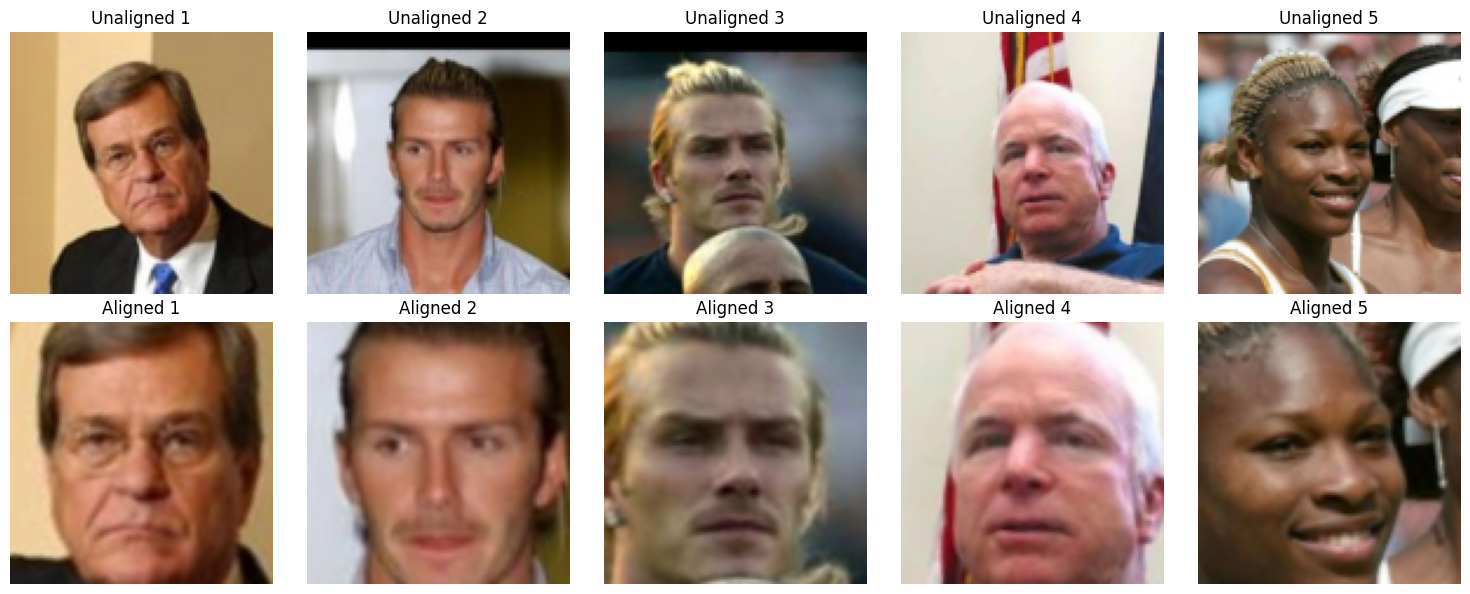

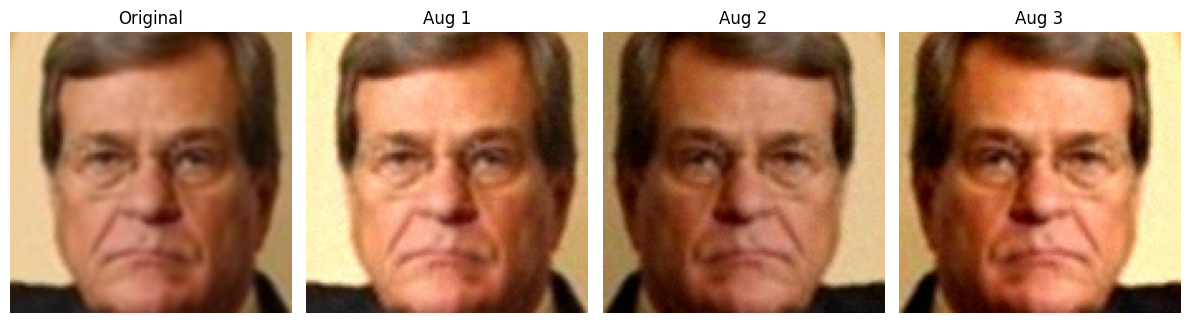

In [6]:
# Alignment + augmentation visual outputs
plot_alignment_examples(
    unaligned_imgs=unaligned_imgs,
    aligned_imgs=aligned_imgs,
    n_examples=5,
    output_path=str(OUT_DIR / "alignment_examples.png"),
)

rgb0 = cv2.cvtColor(aligned_imgs[0], cv2.COLOR_BGR2RGB)
plot_augmentations(
    image_rgb=rgb0,
    train_transform=train_tf,
    n_examples=3,
    output_path=str(OUT_DIR / "augmentation_examples.png"),
)

### Task 3: Face Recognition with Metric Learning

We train a deep face recognition model using:
- Backbone: MobileNetV2
- Loss: ArcFace (Angular Margin Loss)

We also compare with a softmax baseline.

**Files used:** models.py, losses.py, train.py

In [7]:
# Train ArcFace and Softmax baseline
embedding_dim = 512
epochs = 30

arc_model = EmbeddingNet(embedding_dim=embedding_dim)
arc_loss = ArcFaceLoss(embedding_dim=embedding_dim, n_classes=n_classes)
arc_model, arc_hist = train_model(
    model=arc_model,
    loss_module=arc_loss,
    train_ds=aligned_train_ds,
    val_ds=aligned_val_ds,
    device=DEVICE,
    epochs=epochs,
    label="ArcFace",
)

soft_model = EmbeddingNet(embedding_dim=embedding_dim)
soft_loss = SoftmaxHead(embedding_dim=embedding_dim, n_classes=n_classes)
soft_model, soft_hist = train_model(
    model=soft_model,
    loss_module=soft_loss,
    train_ds=aligned_train_ds,
    val_ds=aligned_val_ds,
    device=DEVICE,
    epochs=epochs,
    label="Softmax",
)

arc_unaligned_model = EmbeddingNet(embedding_dim=embedding_dim)
arc_unaligned_loss = ArcFaceLoss(embedding_dim=embedding_dim, n_classes=n_classes)
arc_unaligned_model, _ = train_model(
    model=arc_unaligned_model,
    loss_module=arc_unaligned_loss,
    train_ds=unaligned_train_ds,
    val_ds=aligned_val_ds,
    device=DEVICE,
    epochs=epochs,
    label="ArcFace-Unaligned",
)

# Save checkpoints
torch.save(arc_model.state_dict(), OUT_DIR / "arcface_model.pt")
torch.save(soft_model.state_dict(), OUT_DIR / "softmax_model.pt")

/data/user13/miniconda3/envs/dlcv/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/data/user13/miniconda3/envs/dlcv/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /data/user13/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth
100%|██████████| 13.6M/13.6M [00:00<00:00, 26.0MB/s]


[ArcFace] epoch 001/30 train_loss=33.8947 val_loss=32.3585
[ArcFace] epoch 005/30 train_loss=20.6115 val_loss=21.8079
[ArcFace] epoch 010/30 train_loss=9.6491 val_loss=13.1024
[ArcFace] epoch 015/30 train_loss=2.9613 val_loss=8.5747
[ArcFace] epoch 020/30 train_loss=1.0423 val_loss=7.0470
[ArcFace] epoch 025/30 train_loss=0.4512 val_loss=6.9491
[ArcFace] epoch 030/30 train_loss=0.2715 val_loss=6.8759
[Softmax] epoch 001/30 train_loss=5.2828 val_loss=5.0564
[Softmax] epoch 005/30 train_loss=3.7360 val_loss=3.9098
[Softmax] epoch 010/30 train_loss=3.0690 val_loss=3.0843
[Softmax] epoch 015/30 train_loss=2.6905 val_loss=2.8396
[Softmax] epoch 020/30 train_loss=2.4807 val_loss=2.5674
[Softmax] epoch 025/30 train_loss=2.3870 val_loss=2.4942
[Softmax] epoch 030/30 train_loss=2.3615 val_loss=2.4848
[ArcFace-Unaligned] epoch 001/30 train_loss=34.6836 val_loss=42.5423
[ArcFace-Unaligned] epoch 005/30 train_loss=23.7051 val_loss=44.3846
[ArcFace-Unaligned] epoch 010/30 train_loss=13.2844 val_los

In [15]:
# Extract test embeddings for evaluation
arc_emb, arc_lbl = extract_embeddings(arc_model, aligned_test_ds, device=DEVICE)
soft_emb, soft_lbl = extract_embeddings(soft_model, aligned_test_ds, device=DEVICE)

assert np.array_equal(arc_lbl, soft_lbl), "Label mismatch between models"
test_labels = arc_lbl
print(arc_emb.shape, test_labels.shape)

(510, 512) (510,)


### Task 4A: Verification (6,000 pairs)

ArcFace: VerificationResult(fpr=array([0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.0000

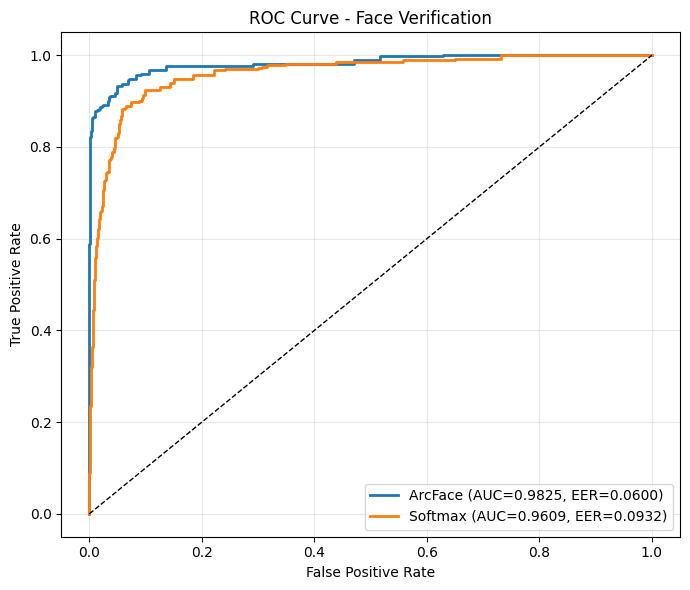

{
  "ArcFace": {
    "AUC": 0.9824708888888889,
    "EER": 0.06000000000000001,
    "TAR@FAR=0.01": 0.8643333333333333,
    "TAR@FAR=0.001": 0.7823333333333333
  },
  "Softmax": {
    "AUC": 0.9608524444444444,
    "EER": 0.09316666666666668,
    "TAR@FAR=0.01": 0.5276666666666666,
    "TAR@FAR=0.001": 0.155
  }
}


In [9]:
arc_ver = evaluate_verification(arc_emb, test_labels, n_same=3000, n_diff=3000, seed=SEED)
soft_ver = evaluate_verification(soft_emb, test_labels, n_same=3000, n_diff=3000, seed=SEED)

print("ArcFace:", arc_ver)
print("Softmax:", soft_ver)

plot_roc_curves(
    [
        {"label": "ArcFace", "fpr": arc_ver.fpr, "tpr": arc_ver.tpr, "auc": arc_ver.auc, "eer": arc_ver.eer},
        {"label": "Softmax", "fpr": soft_ver.fpr, "tpr": soft_ver.tpr, "auc": soft_ver.auc, "eer": soft_ver.eer},
    ],
    output_path=str(OUT_DIR / "task4a_roc.png"),
)

task4a_table = {
    "ArcFace": {
        "AUC": arc_ver.auc,
        "EER": arc_ver.eer,
        "TAR@FAR=0.01": arc_ver.tar_far_001,
        "TAR@FAR=0.001": arc_ver.tar_far_0001,
    },
    "Softmax": {
        "AUC": soft_ver.auc,
        "EER": soft_ver.eer,
        "TAR@FAR=0.01": soft_ver.tar_far_001,
        "TAR@FAR=0.001": soft_ver.tar_far_0001,
    },
}
print(json.dumps(task4a_table, indent=2))

### Task 4B: Identification (100-ID gallery, 50-ID probe)

Using 9 gallery identities and 9 probe identities
ArcFace Rank-1/Rank-5: 0.9444444179534912 1.0
Softmax Rank-1/Rank-5: 0.8888888955116272 1.0


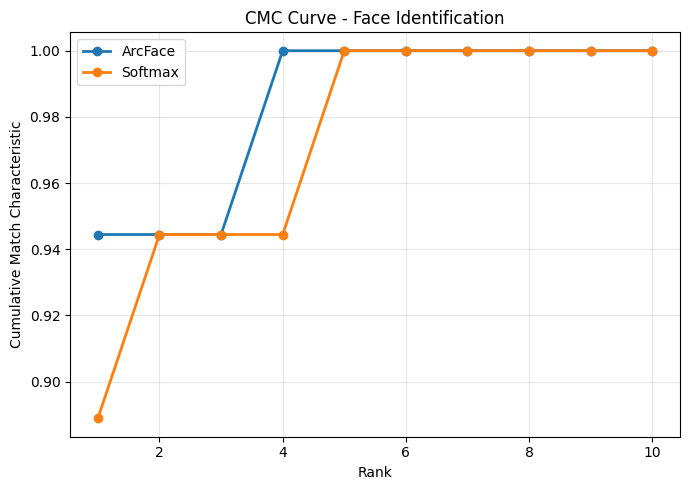

In [11]:
# Choose an identification protocol that fits the available test identities
from collections import Counter

id_counts = Counter(map(int, test_labels))
eligible_ids = [identity for identity, count in id_counts.items() if count >= 7]
if len(eligible_ids) < 2:
    raise ValueError(f"Need at least 2 identities with 7+ samples for identification, got {len(eligible_ids)}")

gallery_identities = min(100, len(eligible_ids))
probe_identities = min(50, gallery_identities)

gallery_idx, probe_idx = build_identification_protocol(
    test_labels,
    gallery_identities=gallery_identities,
    gallery_per_id=5,
    probe_identities=probe_identities,
    probe_per_id=2,
    seed=SEED,
)

arc_ident = evaluate_identification(arc_emb, test_labels, gallery_idx, probe_idx, max_rank=10)
soft_ident = evaluate_identification(soft_emb, test_labels, gallery_idx, probe_idx, max_rank=10)

print(f"Using {gallery_identities} gallery identities and {probe_identities} probe identities")
print("ArcFace Rank-1/Rank-5:", arc_ident.rank1, arc_ident.rank5)
print("Softmax Rank-1/Rank-5:", soft_ident.rank1, soft_ident.rank5)

plot_cmc_curves(
    [
        {"label": "ArcFace", "cmc": arc_ident.cmc},
        {"label": "Softmax", "cmc": soft_ident.cmc},
    ],
    max_rank=10,
    output_path=str(OUT_DIR / "task4b_cmc.png"),
)

### Task 4C: Natural LFW challenge subsets (no synthetic corruption)

{
  "pose": {
    "easy_acc": 1.0,
    "hard_acc": 1.0,
    "drop_pct": 0.0,
    "easy_count": 16.0,
    "hard_count": 1.0,
    "easy_name": "frontal",
    "hard_name": "profile"
  },
  "lighting": {
    "easy_acc": 1.0,
    "hard_acc": 0.9166666666666666,
    "drop_pct": 8.333333325000003,
    "easy_count": 6.0,
    "hard_count": 12.0,
    "easy_name": "normal",
    "hard_name": "poor"
  },
  "occlusion": {
    "easy_acc": 0.9411764705882353,
    "hard_acc": 1.0,
    "drop_pct": -6.249999993359377,
    "easy_count": 17.0,
    "hard_count": 1.0,
    "easy_name": "unoccluded",
    "hard_name": "occluded"
  }
}


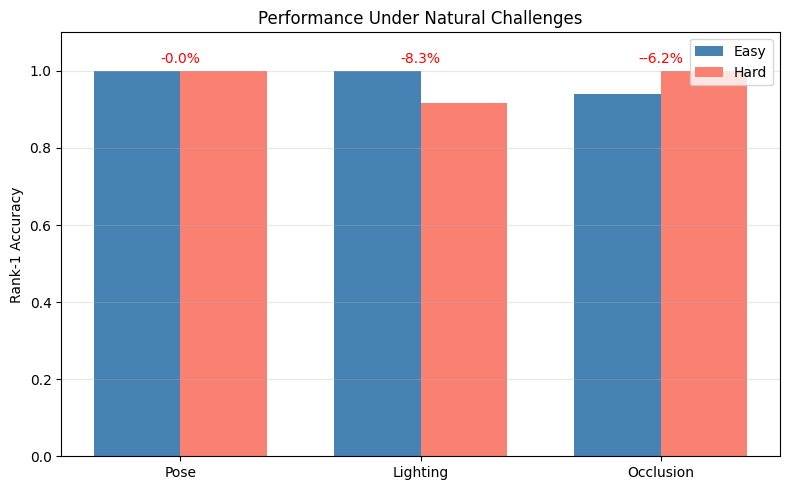

In [12]:
# Build landmarks/boxes for test images to classify natural conditions
inv_test_images = [aligned_imgs[i] for i in te_idx]
landmarks = []
boxes = []
for img in inv_test_images:
    lm = aligner.get_landmarks(img)
    landmarks.append(lm)
    if lm is not None:
        x, y, w, h = cv2.boundingRect(lm.astype(np.int32))
        boxes.append((x, y, w, h))
    else:
        boxes.append(None)

challenge_split = classify_challenge_conditions(inv_test_images, landmarks, boxes)
challenge_results = evaluate_challenge_drop(
    embeddings=arc_emb,
    labels=test_labels,
    gallery_indices=gallery_idx,
    probe_indices=probe_idx,
    challenge_split=challenge_split,
)

print(json.dumps(challenge_results, indent=2))
plot_challenge_drop(challenge_results, output_path=str(OUT_DIR / "task4c_challenges.png"))

### Task 4D: Embedding space (t-SNE, 20+ identities)

/data/user13/miniconda3/envs/dlcv/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/data/user13/miniconda3/envs/dlcv/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


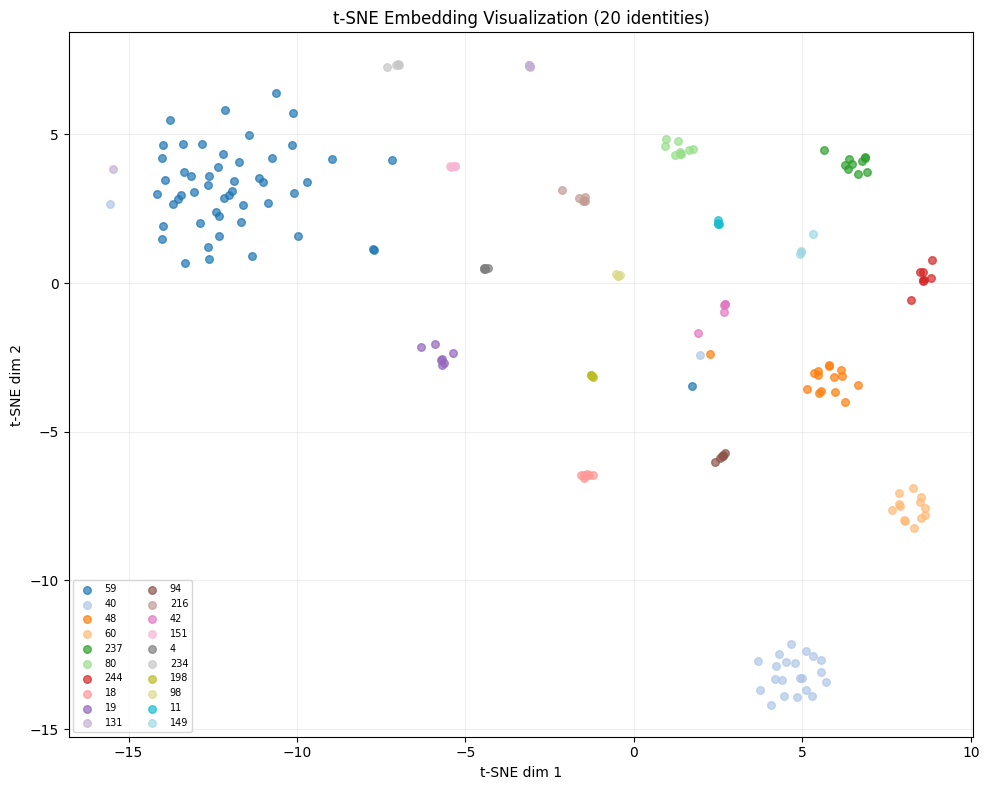

{'mean_intra_distance': 0.10466329095599887, 'mean_inter_centroid_distance': 0.986990596478434}


In [11]:
if "arc_emb" not in globals() or "test_labels" not in globals():
    if "aligned_test_ds" not in globals():
        raise NameError("aligned_test_ds is missing. Run the preprocessing and training cells before Task 4D.")

    if "arc_model" not in globals():
        arc_model = EmbeddingNet(embedding_dim=512)
        arc_model.load_state_dict(torch.load(OUT_DIR / "arcface_model.pt", map_location=DEVICE))
        arc_model.to(DEVICE)
        arc_model.eval()

    arc_emb, arc_lbl = extract_embeddings(arc_model, aligned_test_ds, device=DEVICE)
    test_labels = arc_lbl

plot_tsne_embeddings(
    embeddings=arc_emb,
    labels=test_labels,
    n_identities=20,
    output_path=str(OUT_DIR / "task4d_tsne.png"),
)

# Compactness/separation diagnostics
from collections import defaultdict

by_id = defaultdict(list)
for emb, lbl in zip(arc_emb, test_labels):
    by_id[int(lbl)].append(emb)

intra = []
centroids = {}
for k, vals in by_id.items():
    arr = np.vstack(vals)
    c = arr.mean(axis=0)
    c = c / (np.linalg.norm(c) + 1e-9)
    centroids[k] = c
    if len(arr) > 1:
        sims = arr @ c
        intra.append(float(1.0 - sims.mean()))

keys = list(centroids.keys())
inter = []
for i in range(len(keys)):
    for j in range(i + 1, len(keys)):
        inter.append(float(1.0 - np.dot(centroids[keys[i]], centroids[keys[j]])))

print({
    "mean_intra_distance": float(np.mean(intra)) if intra else None,
    "mean_inter_centroid_distance": float(np.mean(inter)) if inter else None,
})

### Export deliverables (figures, metrics, top-5 matches)

/data/user13/miniconda3/envs/dlcv/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/data/user13/miniconda3/envs/dlcv/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


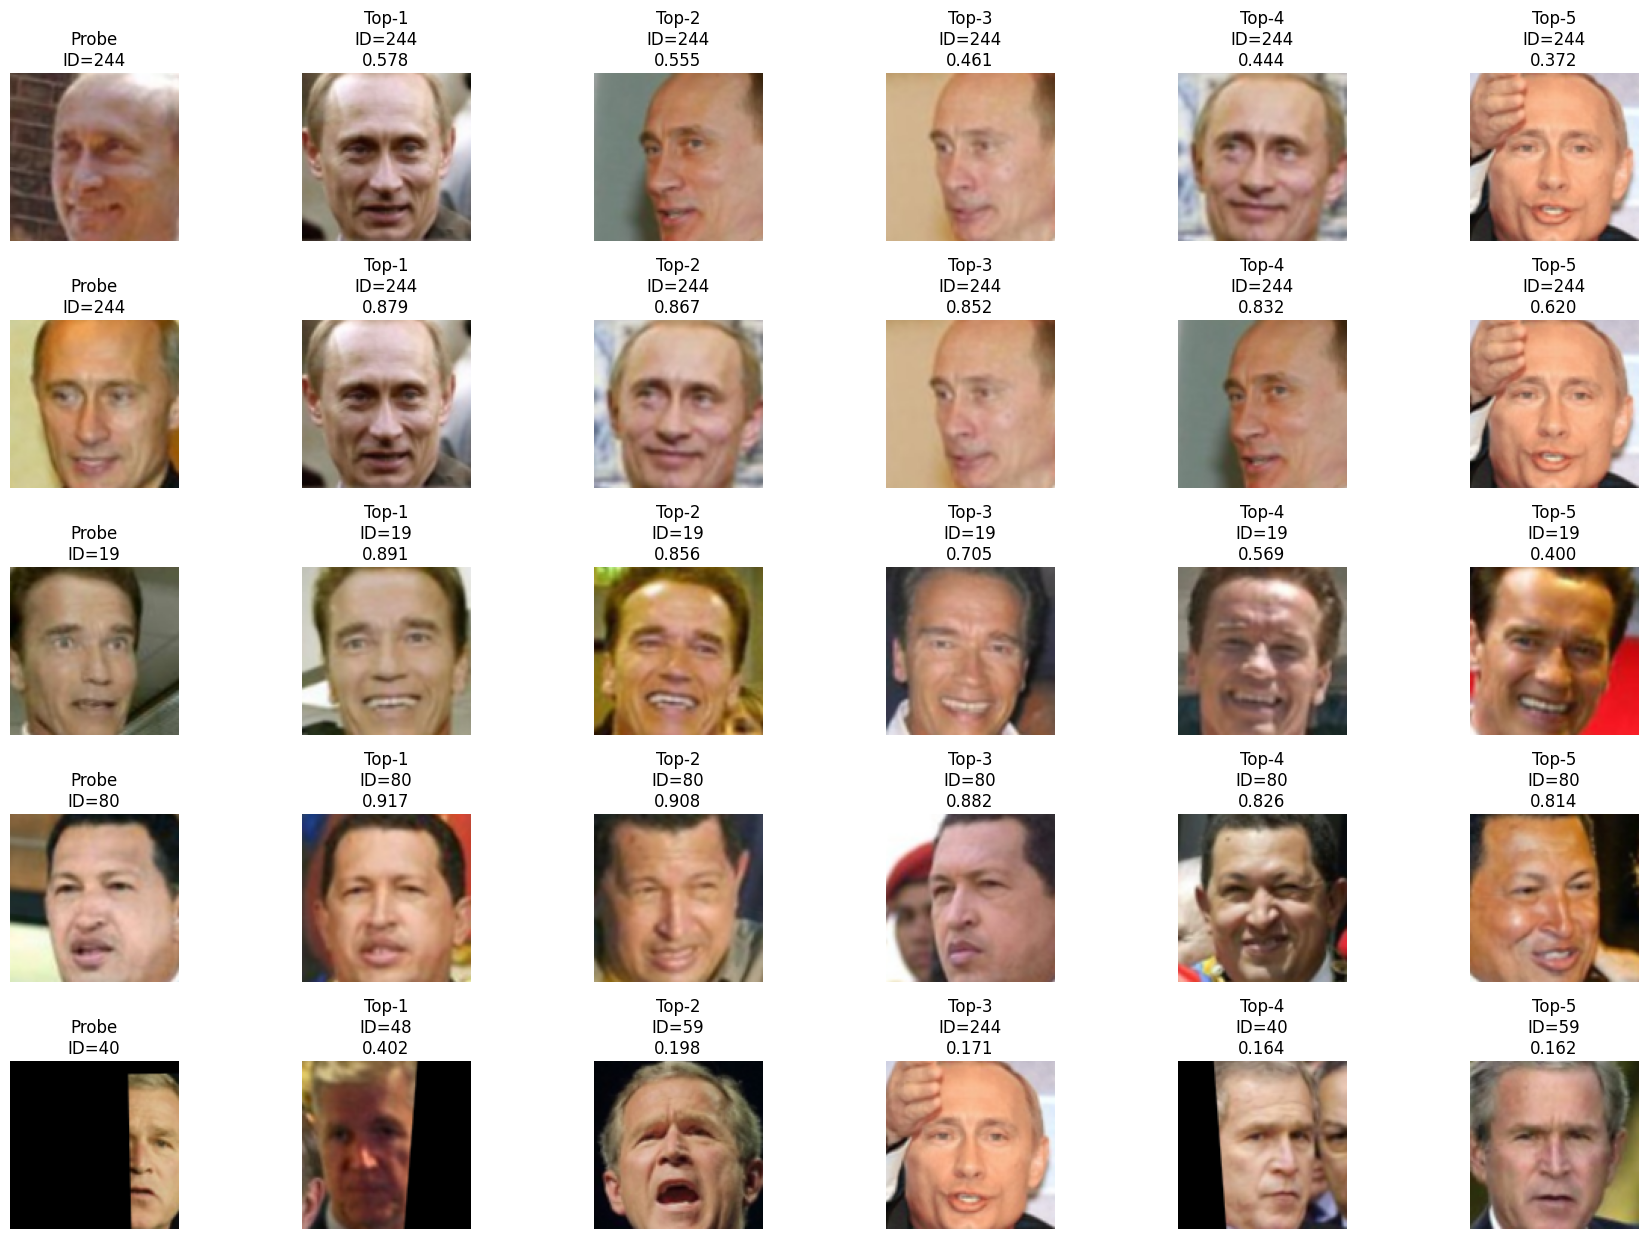

Saved metrics and figures to outputs/


In [14]:
# Rebuild any missing evaluation state so this cell can run after a kernel reset
from collections import Counter

if "arc_emb" not in globals() or "test_labels" not in globals():
    if "aligned_test_ds" not in globals():
        raise NameError("aligned_test_ds is missing. Run the preprocessing and training cells before exporting deliverables.")

    if "arc_model" not in globals():
        arc_model = EmbeddingNet(embedding_dim=512)
        arc_model.load_state_dict(torch.load(OUT_DIR / "arcface_model.pt", map_location=DEVICE))
        arc_model.to(DEVICE)
        arc_model.eval()

    arc_emb, arc_lbl = extract_embeddings(arc_model, aligned_test_ds, device=DEVICE)
    test_labels = arc_lbl

if "task4a_table" not in globals():
    if "soft_emb" not in globals() or "arc_ver" not in globals() or "soft_ver" not in globals():
        if "soft_model" not in globals():
            soft_model = EmbeddingNet(embedding_dim=512)
            soft_model.load_state_dict(torch.load(OUT_DIR / "softmax_model.pt", map_location=DEVICE))
            soft_model.to(DEVICE)
            soft_model.eval()

        soft_emb, soft_lbl = extract_embeddings(soft_model, aligned_test_ds, device=DEVICE)
        if not np.array_equal(test_labels, soft_lbl):
            raise ValueError("Label mismatch between ArcFace and Softmax embeddings.")

        arc_ver = evaluate_verification(arc_emb, test_labels, n_same=3000, n_diff=3000, seed=SEED)
        soft_ver = evaluate_verification(soft_emb, test_labels, n_same=3000, n_diff=3000, seed=SEED)

    task4a_table = {
        "ArcFace": {
            "AUC": arc_ver.auc,
            "EER": arc_ver.eer,
            "TAR@FAR=0.01": arc_ver.tar_far_001,
            "TAR@FAR=0.001": arc_ver.tar_far_0001,
        },
        "Softmax": {
            "AUC": soft_ver.auc,
            "EER": soft_ver.eer,
            "TAR@FAR=0.01": soft_ver.tar_far_001,
            "TAR@FAR=0.001": soft_ver.tar_far_0001,
        },
    }

if "gallery_idx" not in globals() or "probe_idx" not in globals() or "arc_ident" not in globals() or "soft_ident" not in globals():
    id_counts = Counter(map(int, test_labels))
    eligible_ids = [identity for identity, count in id_counts.items() if count >= 7]
    if len(eligible_ids) < 2:
        raise ValueError(f"Need at least 2 identities with 7+ samples for identification, got {len(eligible_ids)}")

    gallery_identities = min(100, len(eligible_ids))
    probe_identities = min(50, gallery_identities)
    gallery_idx, probe_idx = build_identification_protocol(
        test_labels,
        gallery_identities=gallery_identities,
        gallery_per_id=5,
        probe_identities=probe_identities,
        probe_per_id=2,
        seed=SEED,
    )

    arc_ident = evaluate_identification(arc_emb, test_labels, gallery_idx, probe_idx, max_rank=10)
    soft_ident = evaluate_identification(soft_emb, test_labels, gallery_idx, probe_idx, max_rank=10)

if "inv_test_images" not in globals():
    if "aligned_imgs" not in globals() or "te_idx" not in globals():
        raise NameError("aligned_imgs or te_idx is missing. Run the preprocessing cell before exporting deliverables.")
    inv_test_images = [aligned_imgs[i] for i in te_idx]

if "challenge_results" not in globals():
    landmarks = []
    boxes = []
    for img in inv_test_images:
        lm = aligner.get_landmarks(img)
        landmarks.append(lm)
        if lm is not None:
            x, y, w, h = cv2.boundingRect(lm.astype(np.int32))
            boxes.append((x, y, w, h))
        else:
            boxes.append(None)

    challenge_split = classify_challenge_conditions(inv_test_images, landmarks, boxes)
    challenge_results = evaluate_challenge_drop(
        embeddings=arc_emb,
        labels=test_labels,
        gallery_indices=gallery_idx,
        probe_indices=probe_idx,
        challenge_split=challenge_split,
    )

# Top-5 match visualization for 5 probes
examples = topk_gallery_matches(
    embeddings=arc_emb,
    labels=test_labels,
    gallery_indices=gallery_idx,
    probe_indices=probe_idx,
    k=5,
    n_examples=5,
    seed=SEED,
)
plot_top5_matches(examples, inv_test_images, output_path=str(OUT_DIR / "task4_top5_matches.png"))

metrics = {
    "task4a": task4a_table,
    "task4b": {
        "ArcFace": {"rank1": arc_ident.rank1, "rank5": arc_ident.rank5},
        "Softmax": {"rank1": soft_ident.rank1, "rank5": soft_ident.rank5},
    },
    "task4c": challenge_results,
    "protocol": {
        "gallery_size": int(arc_ident.gallery_size),
        "probe_size": int(arc_ident.probe_size),
    },
}

with open(OUT_DIR / "metrics_summary.json", "w", encoding="utf-8") as f:
    json.dump(metrics, f, indent=2)

print("Saved metrics and figures to outputs/")